# 05 - Results Summary and Figure Regeneration

## 1. Notebook Goal
Aggregate all saved Phase 2 artifacts into final tables and figures without rerunning inference.

## 2. Experimental Design
- Load evaluation, imbalance, and continual-learning JSON outputs.
- Prefer no-alpha evaluation results when that artifact exists.
- Regenerate publication figures with consistent styling.
- Build a consolidated final CSV for reporting and comparisons.
- Print final overall and per-class summaries for quick review.

## 3. Inputs
- results/phase2/evaluation_results.json or evaluation_no_alpha_results.json
- results/phase2/imbalance_results.json
- results/phase2/continual_learning_results.json

## 4. Outputs
- figures/phase2/ regenerated summary plots
- results/phase2/final_results_summary.csv
- notebook-printed summary tables

## 5. Execution Guide
Run the notebook in order after upstream experiments are complete to refresh final report artifacts.

### Cell 2 - Imports, Paths, and Figure Directory Setup
Purpose: import required helpers, resolve result-file paths, choose tuned vs no-alpha evaluation source, and ensure output directories exist.

In [17]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from cycler import cycler

sys.path.insert(0, str(Path("../..").resolve()))

from src.phase2.config import get_phase2_config
from src.phase2.evaluation import load_results
from src.phase2.visualization import (
    plot_alpha_sensitivity,
    plot_confusion_matrices,
    plot_continual_learning_curve,
    plot_minority_f1_vs_imbalance,
    plot_phase2_vs_phase1,
    plot_scoring_comparison,
)

CONFIG = get_phase2_config()

REPO_ROOT = Path("../..").resolve()
EVAL_PATH_DEFAULT = REPO_ROOT / "results" / "phase2" / "evaluation_results.json"
EVAL_PATH_NO_ALPHA = REPO_ROOT / "results" / "phase2" / "evaluation_no_alpha_results.json"
EVAL_PATHS = {
    "tuned": EVAL_PATH_DEFAULT,
    "no_alpha": EVAL_PATH_NO_ALPHA,
}

# Reporting mode options: "auto", "tuned", "no_alpha", or "both"
EVAL_MODE = "auto"

if EVAL_MODE not in {"auto", "tuned", "no_alpha", "both"}:
    raise ValueError(
        f"Unsupported EVAL_MODE={EVAL_MODE!r}. Expected one of: auto, tuned, no_alpha, both."
    )

if EVAL_MODE == "auto":
    if EVAL_PATH_NO_ALPHA.exists():
        selected_eval_keys = ["no_alpha"]
    elif EVAL_PATH_DEFAULT.exists():
        selected_eval_keys = ["tuned"]
    else:
        raise FileNotFoundError(
            "Missing evaluation results. Expected evaluation_results.json or evaluation_no_alpha_results.json."
        )
elif EVAL_MODE == "both":
    selected_eval_keys = [key for key, path in EVAL_PATHS.items() if path.exists()]
    if not selected_eval_keys:
        raise FileNotFoundError(
            "EVAL_MODE='both' requested, but neither tuned nor no-alpha evaluation file was found."
        )
else:
    selected_eval_keys = [EVAL_MODE]
    if not EVAL_PATHS[EVAL_MODE].exists():
        raise FileNotFoundError(
            f"Requested EVAL_MODE='{EVAL_MODE}', but file was not found: {EVAL_PATHS[EVAL_MODE]}"
        )

selected_eval_paths = {key: EVAL_PATHS[key] for key in selected_eval_keys}
PRIMARY_EVAL_KEY = "no_alpha" if "no_alpha" in selected_eval_paths else selected_eval_keys[0]
PRIMARY_EVAL_PATH = selected_eval_paths[PRIMARY_EVAL_KEY]

IMB_PATH = REPO_ROOT / "results" / "phase2" / "imbalance_results.json"
CONT_PATH = REPO_ROOT / "results" / "phase2" / "continual_learning_results.json"
FIG_DIR = REPO_ROOT / "figures" / "phase2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not IMB_PATH.exists():
    raise FileNotFoundError(f"Missing imbalance results file: {IMB_PATH}")
if not CONT_PATH.exists():
    raise FileNotFoundError(f"Missing continual-learning results file: {CONT_PATH}")

print(f"Evaluation mode: {EVAL_MODE}")
print(f"Primary evaluation payload: {PRIMARY_EVAL_KEY} -> {PRIMARY_EVAL_PATH.name}")
print("Loaded evaluation payload candidates:")
for key, path in selected_eval_paths.items():
    print(f"  - {key}: {path.name}")

Evaluation mode: auto
Primary evaluation payload: no_alpha -> evaluation_no_alpha_results.json
Loaded evaluation payload candidates:
  - no_alpha: evaluation_no_alpha_results.json


### Cell 3 - Load Saved Experiment Outputs
Purpose: read persisted JSON artifacts for evaluation, imbalance, and continual-learning so all subsequent reporting is reproducible and file-driven.

In [18]:
evaluation_payloads = {
    key: load_results(str(path)) for key, path in selected_eval_paths.items()
}
evaluation_results = evaluation_payloads[PRIMARY_EVAL_KEY]
imbalance_results = load_results(str(IMB_PATH))
continual_results = load_results(str(CONT_PATH))

print(f"Primary payload selected for reporting: {PRIMARY_EVAL_KEY}")
print(f"Primary variants available: {list(evaluation_results.get('variants', {}).keys())}")
if len(evaluation_payloads) > 1:
    print("Multi-mode comparison enabled for tuned vs fixed-alpha reporting.")

Primary payload selected for reporting: no_alpha
Primary variants available: ['majority_vote', 'idw', 'global_dnds', 'local_dnds', 'kde_dnds', 'traditional']


### Cell 4 - Outcome Snapshot and Publication Table Exports
Purpose: compute headline outcomes, derive deltas versus the traditional baseline, and export paper-ready summary tables (CSV and LaTeX).

In [19]:
import csv
import pandas as pd

SUMMARY_CSV_PATH = REPO_ROOT / "results" / "phase2" / "final_results_summary.csv"
PAPER_TABLE_CSV_PATH = REPO_ROOT / "results" / "phase2" / "paper_main_results.csv"
PAPER_TABLE_TEX_PATH = REPO_ROOT / "results" / "phase2" / "paper_main_results.tex"
MODE_COMPARISON_CSV_PATH = REPO_ROOT / "results" / "phase2" / "tuned_vs_fixed_alpha_summary.csv"

SUMMARY_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)


def _pick_ratio_key(payload: dict) -> str | None:
    ratios = [str(r) for r in payload.get("ratios", [])]
    if "10" in ratios:
        return "10"
    if ratios:
        return max(ratios, key=lambda x: int(x))
    return None


def _compute_ttr_gain(payload: dict, selected_ratio: str | None) -> float:
    if selected_ratio is None:
        return 0.0
    variants = payload.get("variants", {})
    local_ttr = (
        variants.get("local_dnds", {})
        .get(selected_ratio, {})
        .get("per_class_f1", {})
        .get("TTR", 0.0)
    )
    other_ttr = [
        metrics.get(selected_ratio, {}).get("per_class_f1", {}).get("TTR", 0.0)
        for name, metrics in variants.items()
        if name != "local_dnds"
    ]
    best_other_ttr = max(other_ttr) if other_ttr else 0.0
    return local_ttr - best_other_ttr


ratio_key = _pick_ratio_key(imbalance_results)
gain = _compute_ttr_gain(imbalance_results, ratio_key)

alpha_tuning_enabled = evaluation_results.get("alpha_tuning", {}).get("enabled", True)
best_alpha_local = evaluation_results.get(
    "best_alpha_local", evaluation_results.get("best_alpha", "n/a")
)
best_alpha_kde = evaluation_results.get(
    "best_alpha_kde", evaluation_results.get("best_alpha", "n/a")
)
alpha_setting = (
    f"tuned(local={best_alpha_local},kde={best_alpha_kde})"
    if alpha_tuning_enabled
    else f"fixed(local={best_alpha_local},kde={best_alpha_kde})"
)

variants = evaluation_results.get("variants", {})
traditional_metrics = variants.get("traditional", {})
traditional_macro = traditional_metrics.get("macro_f1", 0.0)
traditional_ttr = traditional_metrics.get("per_class_f1", {}).get("TTR", 0.0)
traditional_latency = traditional_metrics.get(
    "inference_time_ms", traditional_metrics.get("latency_ms_per_sample", 0.0)
)

rac_variants = [name for name in variants.keys() if name != "traditional"]
best_variant_name = (
    max(rac_variants, key=lambda name: variants[name].get("macro_f1", 0.0))
    if rac_variants
    else None
)

rows = []
for name, metrics in variants.items():
    macro_f1 = metrics.get("macro_f1", 0.0)
    ttr_f1 = metrics.get("per_class_f1", {}).get("TTR", 0.0)
    latency = metrics.get("inference_time_ms", metrics.get("latency_ms_per_sample", 0.0))
    rows.append(
        {
            "variant": name,
            "accuracy": metrics.get("accuracy", 0.0),
            "macro_f1": macro_f1,
            "weighted_f1": metrics.get("weighted_f1", 0.0),
            "ttr_f1": ttr_f1,
            "inference_time_ms": latency,
            "delta_macro_f1_vs_traditional": macro_f1 - traditional_macro,
            "delta_ttr_f1_vs_traditional": ttr_f1 - traditional_ttr,
            "delta_latency_ms_vs_traditional": latency - traditional_latency,
            "alpha_setting": alpha_setting,
            "source_eval_mode": PRIMARY_EVAL_KEY,
            "source_eval_file": PRIMARY_EVAL_PATH.name,
            "imbalance_ratio_key": ratio_key if ratio_key is not None else "n/a",
            "ttr_gain_selected_ratio_to_best_other": gain,
            "is_best_rac": int(name == best_variant_name),
        }
    )

summary_df = pd.DataFrame(rows).sort_values(
    by=["is_best_rac", "macro_f1"], ascending=[False, False]
).reset_index(drop=True)

summary_headers = [
    "variant",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "ttr_f1",
    "inference_time_ms",
    "delta_macro_f1_vs_traditional",
    "delta_ttr_f1_vs_traditional",
    "delta_latency_ms_vs_traditional",
    "alpha_setting",
    "source_eval_mode",
    "source_eval_file",
    "imbalance_ratio_key",
    "ttr_gain_selected_ratio_to_best_other",
    "is_best_rac",
]

with SUMMARY_CSV_PATH.open("w", encoding="utf-8", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=summary_headers)
    writer.writeheader()
    for record in summary_df[summary_headers].to_dict(orient="records"):
        writer.writerow({key: record.get(key) for key in summary_headers})

paper_df = summary_df[
    [
        "variant",
        "accuracy",
        "macro_f1",
        "ttr_f1",
        "inference_time_ms",
        "delta_macro_f1_vs_traditional",
        "delta_ttr_f1_vs_traditional",
        "delta_latency_ms_vs_traditional",
        "is_best_rac",
    ]
]
paper_df.to_csv(PAPER_TABLE_CSV_PATH, index=False)
paper_df.to_latex(PAPER_TABLE_TEX_PATH, index=False, float_format="%.4f")

mode_comparison_df = None
if len(evaluation_payloads) > 1:
    mode_rows = []
    for mode_name, payload in evaluation_payloads.items():
        mode_variants = payload.get("variants", {})
        mode_rac = [k for k in mode_variants.keys() if k != "traditional"]
        if mode_rac:
            mode_best = max(
                mode_rac, key=lambda k: mode_variants[k].get("macro_f1", 0.0)
            )
            mode_best_metrics = mode_variants[mode_best]
            mode_rows.append(
                {
                    "mode": mode_name,
                    "best_rac_variant": mode_best,
                    "best_macro_f1": mode_best_metrics.get("macro_f1", 0.0),
                    "best_ttr_f1": mode_best_metrics.get("per_class_f1", {}).get("TTR", 0.0),
                    "best_latency_ms": mode_best_metrics.get(
                        "inference_time_ms",
                        mode_best_metrics.get("latency_ms_per_sample", 0.0),
                    ),
                    "best_alpha_local": payload.get("best_alpha_local", "n/a"),
                    "best_alpha_kde": payload.get("best_alpha_kde", "n/a"),
                }
            )
    if mode_rows:
        mode_comparison_df = pd.DataFrame(mode_rows).sort_values("mode")
        mode_comparison_df.to_csv(MODE_COMPARISON_CSV_PATH, index=False)

print("=" * 70)
print("OUTCOME SNAPSHOT")
print("=" * 70)
print(f"Primary reporting mode: {PRIMARY_EVAL_KEY} ({PRIMARY_EVAL_PATH.name})")
if best_variant_name is None:
    print("No RAC variants were found in the selected evaluation payload.")
else:
    best_metrics = variants[best_variant_name]
    print(f"Best RAC variant: {best_variant_name}")
    print(
        f"Macro F1={best_metrics.get('macro_f1', 0.0):.4f} (delta vs traditional: {best_metrics.get('macro_f1', 0.0) - traditional_macro:+.4f})"
    )
    print(
        f"TTR F1={best_metrics.get('per_class_f1', {}).get('TTR', 0.0):.4f} (delta vs traditional: {best_metrics.get('per_class_f1', {}).get('TTR', 0.0) - traditional_ttr:+.4f})"
    )
    best_latency = best_metrics.get(
        "inference_time_ms", best_metrics.get("latency_ms_per_sample", 0.0)
    )
    print(
        f"Latency={best_latency:.2f} ms (delta vs traditional: {best_latency - traditional_latency:+.2f} ms)"
    )
if ratio_key is None:
    print("Imbalance gain summary: unavailable")
else:
    print(f"Imbalance gain at {ratio_key}:1 (local_dnds vs best other): {gain:+.4f}")

if mode_comparison_df is not None:
    print("\nTuned vs Fixed-Alpha Comparison (best RAC per mode):")
    print(mode_comparison_df.to_string(index=False))

print(f"Saved consolidated final CSV: {SUMMARY_CSV_PATH}")
print(f"Saved paper table CSV: {PAPER_TABLE_CSV_PATH}")
print(f"Saved paper table LaTeX: {PAPER_TABLE_TEX_PATH}")
if mode_comparison_df is not None:
    print(f"Saved mode comparison CSV: {MODE_COMPARISON_CSV_PATH}")

OUTCOME SNAPSHOT
Primary reporting mode: no_alpha (evaluation_no_alpha_results.json)
Best RAC variant: global_dnds
Macro F1=0.8481 (delta vs traditional: +0.0401)
TTR F1=0.8706 (delta vs traditional: +0.0500)
Latency=412.54 ms (delta vs traditional: +411.08 ms)
Imbalance gain at 10:1 (local_dnds vs best other): -0.1135
Saved consolidated final CSV: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\final_results_summary.csv
Saved paper table CSV: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\paper_main_results.csv
Saved paper table LaTeX: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\paper_main_results.tex


### Cell 5 - Figure Dashboard (Dedicated Sections)
Purpose: render grouped figure sections for evaluation, imbalance, continual learning, efficiency trade-offs, and per-class deltas versus baseline so outcomes are easier to interpret at a glance.

SECTION A - CORE EVALUATION FIGURES

[Figure] Macro F1 by Scoring Variant


D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\src\phase2\visualization.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=variants, y=macro_f1, ax=ax, palette=bar_colors)


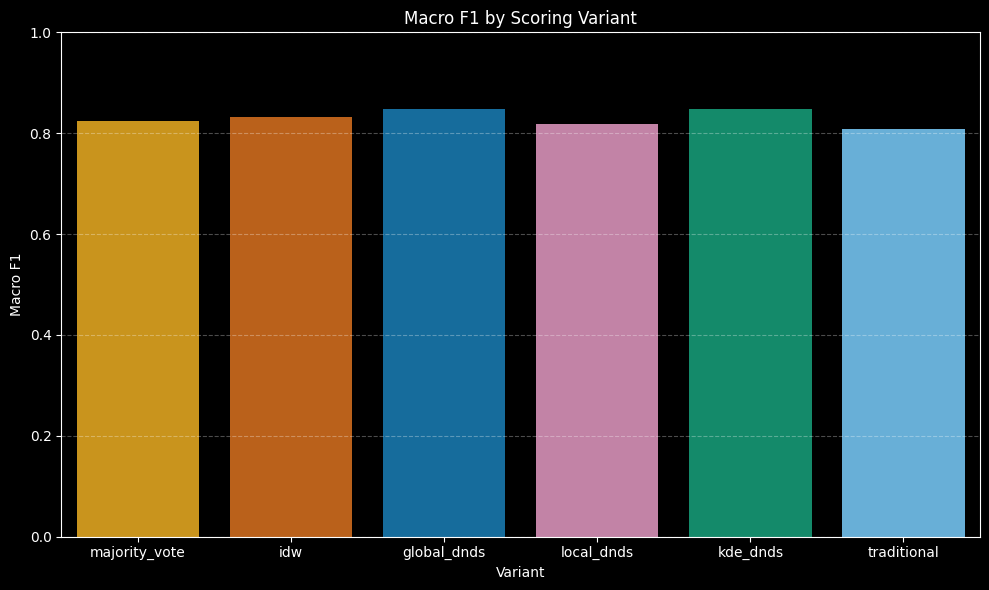

Alpha sweep data not found; skipping alpha sensitivity figure.

[Figure] Confusion Matrices


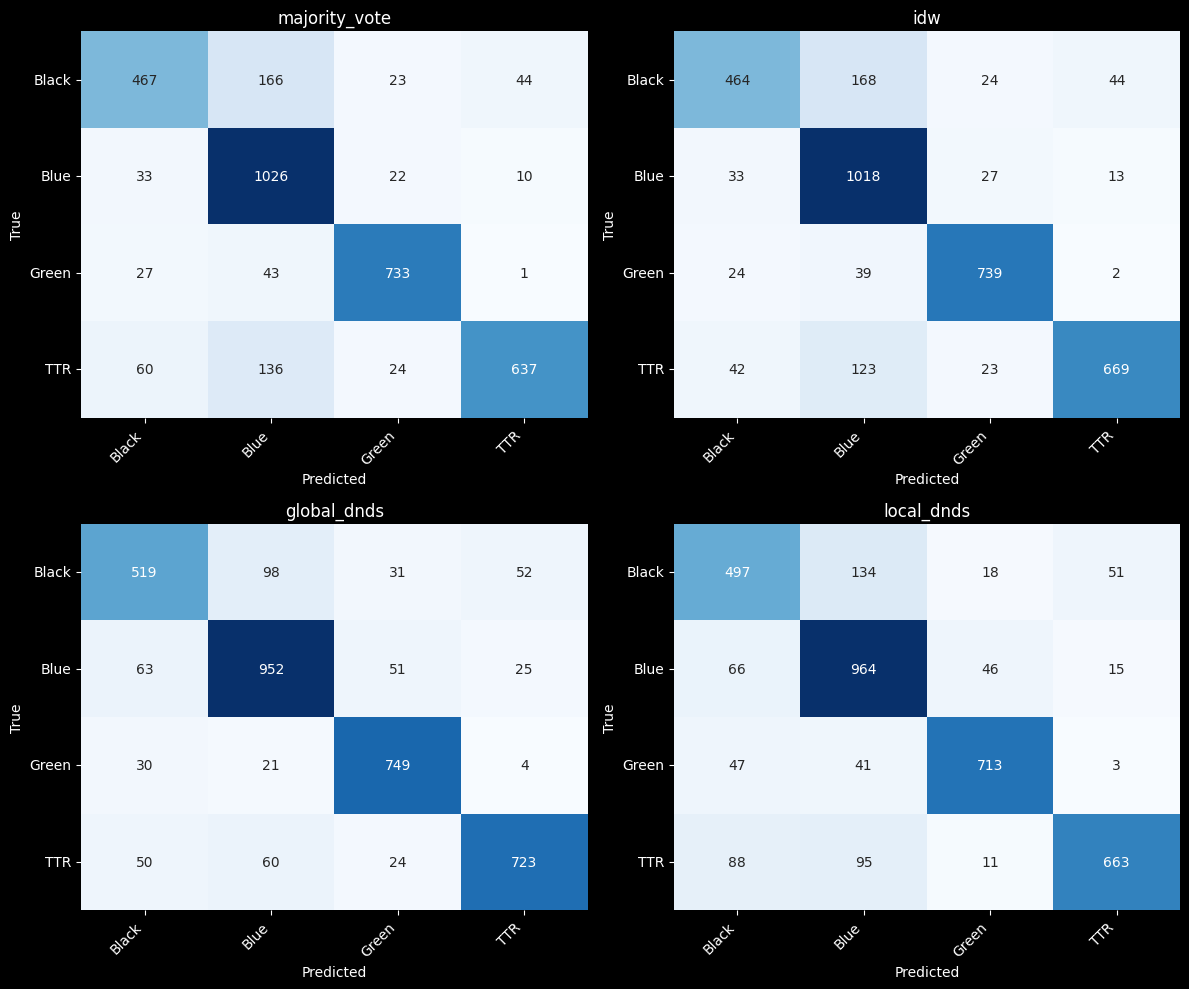


[Figure] Phase 2 Best RAC vs Phase 1


D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\src\phase2\visualization.py:310: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette=["#6c757d", "#2a9d8f"], ax=ax)


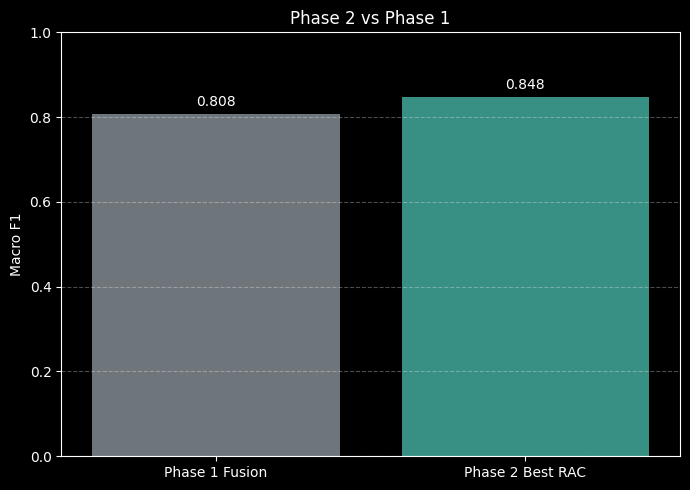


SECTION B - IMBALANCE EXPERIMENT FIGURES

[Figure] Minority-Class F1 vs Imbalance


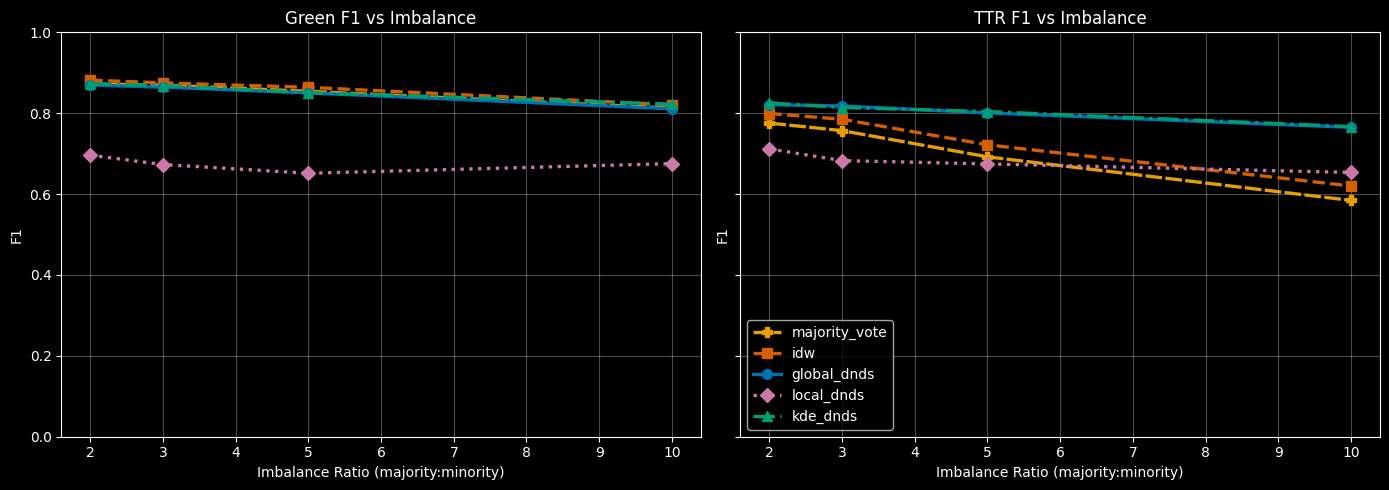


[Figure] Overall Imbalance Outcome (Macro F1)


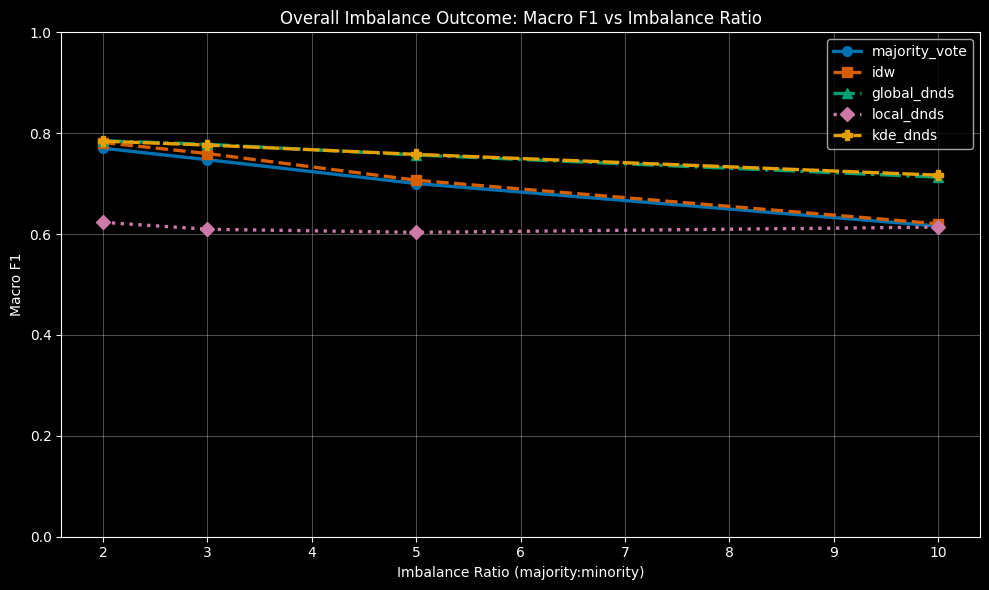


SECTION C - CONTINUAL LEARNING FIGURE

[Figure] Continual Learning Curve


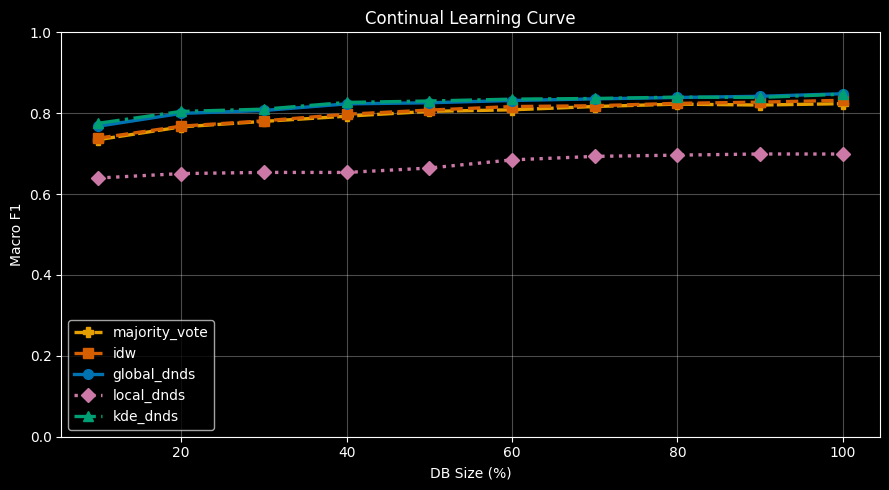


SECTION D - EFFICIENCY VS EFFECTIVENESS

[Figure] Effectiveness vs Efficiency


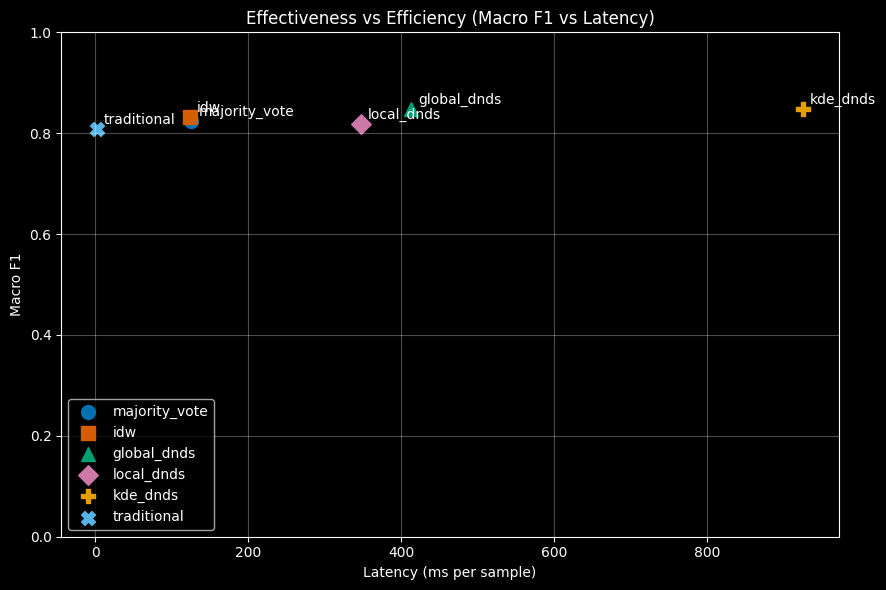


SECTION E - PER-CLASS DELTA HEATMAP

[Figure] Per-Class F1 Delta Heatmap


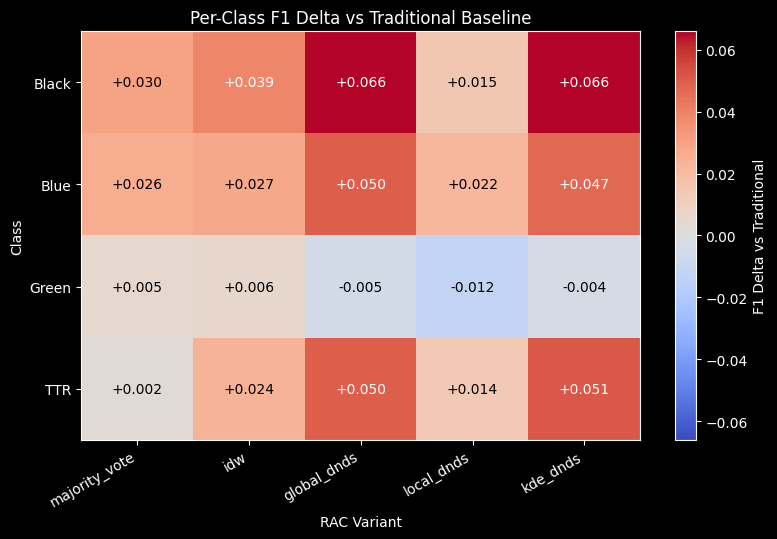

In [20]:
from IPython.display import display

# Match the visual style used in 03_imbalance_experiment.ipynb
variant_palette = [
    "#0072B2",
    "#D55E00",
    "#009E73",
    "#CC79A7",
    "#E69F00",
    "#56B4E9",
    "#000000",
    "#F0E442",
]
variant_markers = ["o", "s", "^", "D", "P", "X", "v", "*"]
variant_linestyles = [
    "-",
    "--",
    "-.",
    ":",
    (0, (5, 1)),
    (0, (3, 1, 1, 1)),
    (0, (1, 1)),
    (0, (3, 5, 1, 5)),
]
plt.rcParams["axes.prop_cycle"] = (
    cycler(color=variant_palette)
    + cycler(marker=variant_markers)
    + cycler(linestyle=variant_linestyles)
)
plt.rcParams["lines.linewidth"] = 2.4
plt.rcParams["lines.markersize"] = 7
plt.rcParams["grid.alpha"] = 0.35


def _display_and_close(fig, title: str):
    print(f"\n[Figure] {title}")
    display(fig)
    plt.close(fig)


print("=" * 80)
print("SECTION A - CORE EVALUATION FIGURES")
print("=" * 80)
fig = plot_scoring_comparison(
    evaluation_results, str(FIG_DIR / "scoring_comparison.png")
)
_display_and_close(fig, "Macro F1 by Scoring Variant")

alpha_sweep = evaluation_results.get("alpha_sweep")
has_alpha_sweep = bool(alpha_sweep) and any(
    len(series.get("alphas", [])) > 0 for series in alpha_sweep.values()
)
if has_alpha_sweep:
    fig = plot_alpha_sensitivity(
        evaluation_results["alpha_sweep"], str(FIG_DIR / "alpha_sensitivity.png")
    )
    _display_and_close(fig, "Alpha Sensitivity")
else:
    print("Alpha sweep data not found; skipping alpha sensitivity figure.")

fig = plot_confusion_matrices(
    evaluation_results,
    CONFIG["class_names"],
    str(FIG_DIR / "confusion_matrices_phase2.png"),
)
_display_and_close(fig, "Confusion Matrices")

phase1_macro_f1 = (
    evaluation_results["variants"].get("traditional", {}).get("macro_f1", 0.8177)
)
variants_payload = evaluation_results.get("variants", {})
rac_scores = [
    v.get("macro_f1", 0.0) for k, v in variants_payload.items() if k != "traditional"
]
best_phase2 = max(rac_scores) if rac_scores else 0.0
fig = plot_phase2_vs_phase1(
    best_phase2,
    phase1_macro_f1,
    str(FIG_DIR / "phase2_vs_phase1.png"),
)
_display_and_close(fig, "Phase 2 Best RAC vs Phase 1")

print("\n" + "=" * 80)
print("SECTION B - IMBALANCE EXPERIMENT FIGURES")
print("=" * 80)
fig = plot_minority_f1_vs_imbalance(
    imbalance_results, str(FIG_DIR / "minority_f1_vs_imbalance.png")
)
_display_and_close(fig, "Minority-Class F1 vs Imbalance")

# Overall imbalance outcome graph across all variants (macro F1).
imb_ratios = imbalance_results.get("ratios", [])
imb_variants = imbalance_results.get("variants", {})
fig, ax = plt.subplots(figsize=(10, 6))
for idx, (variant_name, per_ratio) in enumerate(imb_variants.items()):
    macro_values = [per_ratio.get(str(r), {}).get("macro_f1", 0.0) for r in imb_ratios]
    ax.plot(
        imb_ratios,
        macro_values,
        marker=variant_markers[idx % len(variant_markers)],
        linestyle=variant_linestyles[idx % len(variant_linestyles)],
        color=variant_palette[idx % len(variant_palette)],
        linewidth=2.4,
        markersize=7,
        label=variant_name,
    )
ax.set_title("Overall Imbalance Outcome: Macro F1 vs Imbalance Ratio")
ax.set_xlabel("Imbalance Ratio (majority:minority)")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(str(FIG_DIR / "imbalance_overall_macro_f1.png"), dpi=300)
_display_and_close(fig, "Overall Imbalance Outcome (Macro F1)")

print("\n" + "=" * 80)
print("SECTION C - CONTINUAL LEARNING FIGURE")
print("=" * 80)
fig = plot_continual_learning_curve(
    continual_results, str(FIG_DIR / "continual_learning_curve.png")
)
_display_and_close(fig, "Continual Learning Curve")

print("\n" + "=" * 80)
print("SECTION D - EFFICIENCY VS EFFECTIVENESS")
print("=" * 80)
fig, ax = plt.subplots(figsize=(9, 6))
for idx, (variant_name, metrics) in enumerate(variants_payload.items()):
    macro = metrics.get("macro_f1", 0.0)
    latency = metrics.get(
        "inference_time_ms", metrics.get("latency_ms_per_sample", 0.0)
    )
    ax.scatter(
        latency,
        macro,
        s=100,
        marker=variant_markers[idx % len(variant_markers)],
        color=variant_palette[idx % len(variant_palette)],
        label=variant_name,
    )
    ax.annotate(
        variant_name, (latency, macro), textcoords="offset points", xytext=(5, 4)
    )
ax.set_title("Effectiveness vs Efficiency (Macro F1 vs Latency)")
ax.set_xlabel("Latency (ms per sample)")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(str(FIG_DIR / "effectiveness_vs_efficiency.png"), dpi=300)
_display_and_close(fig, "Effectiveness vs Efficiency")

print("\n" + "=" * 80)
print("SECTION E - PER-CLASS DELTA HEATMAP")
print("=" * 80)
class_names = CONFIG.get("class_names", ["Black", "Blue", "Green", "TTR"])
traditional_per_class_f1 = variants_payload.get("traditional", {}).get(
    "per_class_f1", {}
)
rac_names = [name for name in variants_payload.keys() if name != "traditional"]

if rac_names:
    delta_matrix = []
    for cls in class_names:
        base = traditional_per_class_f1.get(cls, 0.0)
        delta_row = []
        for variant_name in rac_names:
            score = (
                variants_payload.get(variant_name, {})
                .get("per_class_f1", {})
                .get(cls, 0.0)
            )
            delta_row.append(score - base)
        delta_matrix.append(delta_row)

    max_abs = max(abs(v) for row in delta_matrix for v in row) if delta_matrix else 0.0
    max_abs = max(max_abs, 1e-3)

    fig, ax = plt.subplots(figsize=(max(8, 1.6 * len(rac_names)), 5.5))
    image = ax.imshow(
        delta_matrix, cmap="coolwarm", vmin=-max_abs, vmax=max_abs, aspect="auto"
    )
    ax.set_title("Per-Class F1 Delta vs Traditional Baseline")
    ax.set_xlabel("RAC Variant")
    ax.set_ylabel("Class")
    ax.set_xticks(range(len(rac_names)))
    ax.set_xticklabels(rac_names, rotation=30, ha="right")
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names)

    for row_idx, row in enumerate(delta_matrix):
        for col_idx, value in enumerate(row):
            text_color = "white" if abs(value) > 0.5 * max_abs else "black"
            ax.text(
                col_idx,
                row_idx,
                f"{value:+.3f}",
                ha="center",
                va="center",
                color=text_color,
            )

    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label("F1 Delta vs Traditional")
    fig.tight_layout()
    fig.savefig(str(FIG_DIR / "per_class_f1_delta_vs_traditional.png"), dpi=300)
    _display_and_close(fig, "Per-Class F1 Delta Heatmap")
else:
    print("No RAC variants available; skipping per-class delta heatmap.")

### Cell 6 - Detailed Metric Tables and Per-Class Breakdown
Purpose: print full metric tables (including deltas versus baseline) and class-wise precision/recall/F1 for RAC variants.

In [21]:
import pandas as pd

alpha_tuning_enabled = evaluation_results.get("alpha_tuning", {}).get("enabled", True)
best_alpha_local = evaluation_results.get(
    "best_alpha_local", evaluation_results.get("best_alpha", "n/a")
)
best_alpha_kde = evaluation_results.get(
    "best_alpha_kde", evaluation_results.get("best_alpha", "n/a")
)

print("=" * 70)
if alpha_tuning_enabled:
    print("PHASE 2 RAC EXPERIMENT (WITH ALPHA TUNING) - DETAILED SUMMARY")
else:
    print("PHASE 2 RAC EXPERIMENT (NO ALPHA TUNING) - DETAILED SUMMARY")
print("=" * 70)
print(f"Primary reporting mode: {PRIMARY_EVAL_KEY}")
print(f"Primary evaluation file: {PRIMARY_EVAL_PATH.name}")
print(f"Alpha setting summary: {alpha_setting}")
if ratio_key is None:
    print("Imbalance ratio key: unavailable")
else:
    print(f"Imbalance ratio key used for gain reporting: {ratio_key}:1")
print("=" * 70)

display_cols = [
    "variant",
    "accuracy",
    "macro_f1",
    "ttr_f1",
    "inference_time_ms",
    "delta_macro_f1_vs_traditional",
    "delta_ttr_f1_vs_traditional",
    "delta_latency_ms_vs_traditional",
    "is_best_rac",
]
detailed_df = summary_df[display_cols].copy()
print(detailed_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

if mode_comparison_df is not None:
    print("\nTUNED VS FIXED-ALPHA (BEST RAC PER MODE)")
    print(mode_comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

traditional_metrics = evaluation_results["variants"].get("traditional", {})
phase1_fused_per_class = traditional_metrics.get(
    "per_class_f1",
    {
        "Black": 0.7141,
        "Blue": 0.8220,
        "Green": 0.9171,
        "TTR": 0.8177,
    },
)

rac_variants = [
    name for name in evaluation_results["variants"].keys() if name != "traditional"
]
best_variant_name = (
    max(
        rac_variants,
        key=lambda name: evaluation_results["variants"][name].get("macro_f1", 0.0),
    )
    if rac_variants
    else "n/a"
)


def _build_wide_per_class_table(metric_key: str) -> pd.DataFrame:
    rows = []
    for cls in ["Black", "Blue", "Green", "TTR"]:
        row = {
            "Class": cls,
            "Phase 1 Fused": phase1_fused_per_class.get(cls, 0.0),
        }
        for variant_name in rac_variants:
            row[variant_name] = (
                evaluation_results["variants"][variant_name]
                .get(metric_key, {})
                .get(cls, 0.0)
            )
        rows.append(row)
    table = pd.DataFrame(rows)
    value_cols = [c for c in table.columns if c != "Class"]
    table[value_cols] = table[value_cols].apply(
        lambda col: col.map(lambda x: f"{x:.4f}")
    )
    return table


print("")
print("Per-Class F1 Table (All RAC Variants)")
f1_table = _build_wide_per_class_table("per_class_f1")
print(f1_table)

print("")
print("Per-Class Precision Table (All RAC Variants)")
precision_table = _build_wide_per_class_table("per_class_precision")
print(precision_table)

print("")
print("Per-Class Recall Table (All RAC Variants)")
recall_table = _build_wide_per_class_table("per_class_recall")
print(recall_table)

print("")
if best_variant_name == "n/a":
    print("Best RAC variant in this run (by Macro F1): n/a")
else:
    print(f"Best RAC variant in this run (by Macro F1): {best_variant_name}")

PHASE 2 RAC EXPERIMENT (NO ALPHA TUNING) - DETAILED SUMMARY
Primary reporting mode: no_alpha
Primary evaluation file: evaluation_no_alpha_results.json
Alpha setting summary: fixed(local=0.5,kde=0.5)
Imbalance ratio key used for gain reporting: 10:1
      variant  accuracy  macro_f1  ttr_f1  inference_time_ms  delta_macro_f1_vs_traditional  delta_ttr_f1_vs_traditional  delta_latency_ms_vs_traditional  is_best_rac
  global_dnds    0.8525    0.8481  0.8706           412.5397                         0.0401                       0.0500                         411.0847            1
     kde_dnds    0.8523    0.8480  0.8716           925.5377                         0.0399                       0.0510                         924.0826            0
          idw    0.8372    0.8319  0.8442           123.7164                         0.0239                       0.0236                         122.2613            0
majority_vote    0.8294    0.8236  0.8225           125.3388                       

### Cell 7 - Key Findings for Paper Write-up
Purpose: auto-generate concise, evidence-backed findings suitable for the Results section narrative.

In [22]:
KEY_FINDINGS_PATH = REPO_ROOT / "results" / "phase2" / "key_findings_phase2.txt"

variants = evaluation_results.get("variants", {})
traditional = variants.get("traditional", {})
traditional_macro = traditional.get("macro_f1", 0.0)
traditional_ttr = traditional.get("per_class_f1", {}).get("TTR", 0.0)
traditional_latency = traditional.get(
    "inference_time_ms", traditional.get("latency_ms_per_sample", 0.0)
)

rac_variants = [k for k in variants.keys() if k != "traditional"]
if rac_variants:
    best_rac = max(rac_variants, key=lambda k: variants[k].get("macro_f1", 0.0))
    best_metrics = variants[best_rac]
    best_macro = best_metrics.get("macro_f1", 0.0)
    best_ttr = best_metrics.get("per_class_f1", {}).get("TTR", 0.0)
    best_latency = best_metrics.get(
        "inference_time_ms", best_metrics.get("latency_ms_per_sample", 0.0)
    )
else:
    best_rac = "n/a"
    best_macro = 0.0
    best_ttr = 0.0
    best_latency = 0.0

finding_lines = [
    "KEY FINDINGS (AUTO-GENERATED)",
    f"- Primary reporting mode: {PRIMARY_EVAL_KEY} ({PRIMARY_EVAL_PATH.name}).",
    f"- Best RAC variant by Macro F1: {best_rac}.",
    f"- Macro F1 improvement vs traditional baseline: {best_macro - traditional_macro:+.4f}.",
    f"- TTR F1 improvement vs traditional baseline: {best_ttr - traditional_ttr:+.4f}.",
    f"- Latency difference vs traditional baseline: {best_latency - traditional_latency:+.2f} ms.",
]

if ratio_key is None:
    finding_lines.append(
        "- Imbalance gain statement unavailable because no imbalance ratio key was found."
    )
else:
    finding_lines.append(
        f"- Minority robustness at {ratio_key}:1: local_dnds TTR gain vs best competing variant = {gain:+.4f}."
    )

if mode_comparison_df is not None and not mode_comparison_df.empty:
    finding_lines.append(
        "- Tuned vs fixed-alpha comparison was enabled; see tuned_vs_fixed_alpha_summary.csv for side-by-side best-RAC metrics."
    )

KEY_FINDINGS_PATH.write_text("\n".join(finding_lines) + "\n", encoding="utf-8")

print("\n".join(finding_lines))
print(f"Saved key findings text: {KEY_FINDINGS_PATH}")

KEY FINDINGS (AUTO-GENERATED)
- Primary reporting mode: no_alpha (evaluation_no_alpha_results.json).
- Best RAC variant by Macro F1: global_dnds.
- Macro F1 improvement vs traditional baseline: +0.0401.
- TTR F1 improvement vs traditional baseline: +0.0500.
- Latency difference vs traditional baseline: +411.08 ms.
- Minority robustness at 10:1: local_dnds TTR gain vs best competing variant = -0.1135.
Saved key findings text: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\key_findings_phase2.txt
